Policy iteration 1, stable = False
Policy iteration 2, stable = False
Policy iteration 3, stable = False
Policy iteration 4, stable = True
Saved 'gbike_policy.npy' and 'gbike_value.npy' in the working directory.


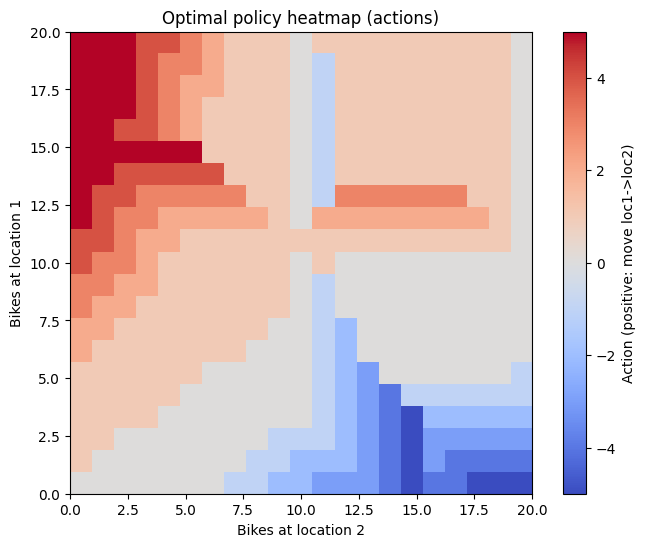

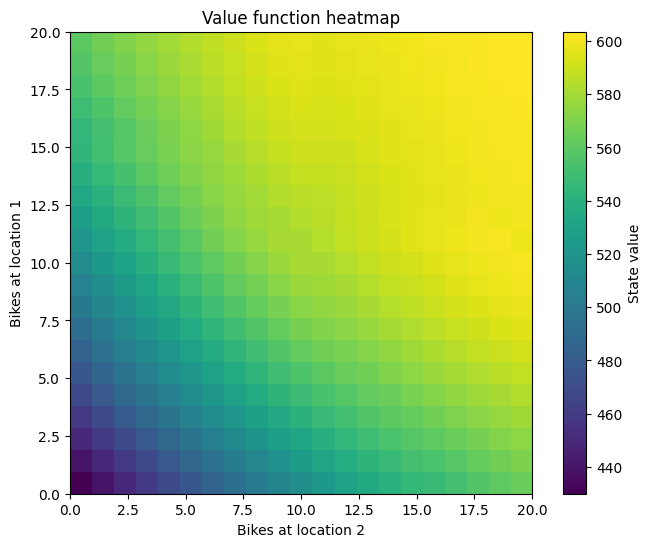

In [1]:
"""
Gbike policy-iteration implementation (modified Jack's car rental).

Run in a Jupyter notebook or Python script. This computes the optimal policy using
policy iteration and saves policy/value arrays and a heatmap.

Notes:
 - For accuracy vs speed tradeoff, increase `cutoff` for Poisson sums if desired.
 - This implementation precomputes transitions for all feasible (state,action).
"""

import numpy as np
from math import exp, factorial
from collections import defaultdict
import matplotlib.pyplot as plt

# -------------------------
# Problem parameters
# -------------------------
max_bikes = 20            # capacity at each location
max_move = 5              # max bikes moved overnight (per night)
rent_reward = 10          # INR per rental
move_cost_per = 2         # INR per bike moved (beyond free shuttle)
parking_threshold = 10    # bikes threshold for extra parking
parking_cost = 4          # INR surcharge if > threshold at a location
gamma = 0.9               # discount factor

# Poisson parameters
req_rate = (3.0, 4.0)     # expected rental requests at loc1 and loc2
ret_rate = (3.0, 2.0)     # expected returns at loc1 and loc2

# truncate Poisson sums at cutoff (increasing cutoff increases accuracy and time)
cutoff = 11

# -------------------------
# States and actions
# -------------------------
states = [(i, j) for i in range(max_bikes+1) for j in range(max_bikes+1)]
n_states = len(states)
state_to_idx = {s: idx for idx, s in enumerate(states)}

actions = np.arange(-max_move, max_move+1)   # negative = move loc2->loc1, positive = loc1->loc2
n_actions = len(actions)

# -------------------------
# Poisson PMF helper and cache
# -------------------------
def poisson_pmf(n, lam):
    return exp(-lam) * lam**n / factorial(n)

poisson_cache = {}
for lam in set(req_rate + ret_rate):
    pmf = np.array([poisson_pmf(k, lam) for k in range(cutoff+1)])
    tail = 1.0 - pmf.sum()
    if tail > 0:
        pmf[-1] += tail
    poisson_cache[lam] = pmf

req_pmf1 = poisson_cache[req_rate[0]]
req_pmf2 = poisson_cache[req_rate[1]]
ret_pmf1 = poisson_cache[ret_rate[0]]
ret_pmf2 = poisson_cache[ret_rate[1]]

# -------------------------
# Precompute transitions and expected immediate rewards
# -------------------------
# trans[s_idx][a_idx] = dict(next_state_idx -> prob)
# rew[s_idx, a_idx] = expected immediate reward (including movement & parking costs)
from collections import defaultdict
trans = [[defaultdict(float) for _ in range(n_actions)] for _ in range(n_states)]
rew = np.zeros((n_states, n_actions))

for s_idx, (b1, b2) in enumerate(states):
    for a_idx, a in enumerate(actions):
        # feasibility checks: cannot move more bikes than available
        if a > 0 and a > b1:
            continue
        if a < 0 and (-a) > b2:
            continue
        nb1 = b1 - a  # after moving (note sign convention)
        nb2 = b2 + a
        if nb1 < 0 or nb1 > max_bikes or nb2 < 0 or nb2 > max_bikes:
            continue

        # movement cost with free shuttle for moves loc1->loc2 (a>0)
        if a > 0:
            move_cost = move_cost_per * max(0, a - 1)  # first one free
        else:
            move_cost = move_cost_per * abs(a)

        # parking surcharge after move
        surcharge = 0
        if nb1 > parking_threshold:
            surcharge += parking_cost
        if nb2 > parking_threshold:
            surcharge += parking_cost
        fixed_cost = move_cost + surcharge

        exp_reward = 0.0
        # iterate over requests and returns (truncated)
        for r1 in range(cutoff+1):
            p_r1 = req_pmf1[r1]
            for r2 in range(cutoff+1):
                p_r2 = req_pmf2[r2]
                rent1 = min(nb1, r1)
                rent2 = min(nb2, r2)
                rental_income = rent_reward * (rent1 + rent2)
                after_r1 = nb1 - rent1
                after_r2 = nb2 - rent2
                prob_req = p_r1 * p_r2
                for ret1 in range(cutoff+1):
                    p_ret1 = ret_pmf1[ret1]
                    for ret2 in range(cutoff+1):
                        p_ret2 = ret_pmf2[ret2]
                        prob = prob_req * p_ret1 * p_ret2
                        next_b1 = min(after_r1 + ret1, max_bikes)
                        next_b2 = min(after_r2 + ret2, max_bikes)
                        next_idx = state_to_idx[(next_b1, next_b2)]
                        immediate = rental_income - fixed_cost
                        exp_reward += prob * immediate
                        trans[s_idx][a_idx][next_idx] += prob
        rew[s_idx, a_idx] = exp_reward

# -------------------------
# Policy iteration
# -------------------------
policy = np.zeros(n_states, dtype=int)  # store action indices
V = np.zeros(n_states)

# initialize policy with a feasible action (prefer 0 if feasible)
for s_idx, _ in enumerate(states):
    feasible = [i for i in range(n_actions) if len(trans[s_idx][i]) > 0]
    if len(feasible) == 0:
        policy[s_idx] = 0
    else:
        if np.where(actions == 0)[0][0] in feasible:
            policy[s_idx] = np.where(actions == 0)[0][0]
        else:
            policy[s_idx] = feasible[0]

def policy_evaluation(policy, V, theta=1e-3):
    while True:
        delta = 0.0
        for s in range(n_states):
            a_idx = policy[s]
            v_old = V[s]
            r_sa = rew[s, a_idx]
            total = 0.0
            for s2, p in trans[s][a_idx].items():
                total += p * V[s2]
            V[s] = r_sa + gamma * total
            delta = max(delta, abs(v_old - V[s]))
        if delta < theta:
            break

def policy_improvement(policy, V):
    stable = True
    for s in range(n_states):
        old_a = policy[s]
        action_values = np.full(n_actions, -1e9)
        for a_idx in range(n_actions):
            if len(trans[s][a_idx]) == 0:
                continue
            r_sa = rew[s, a_idx]
            total = 0.0
            for s2, p in trans[s][a_idx].items():
                total += p * V[s2]
            action_values[a_idx] = r_sa + gamma * total
        best_a = int(np.argmax(action_values))
        if action_values[best_a] <= -1e8:
            best_a = old_a
        policy[s] = best_a
        if best_a != old_a:
            stable = False
    return stable

# iterate until policy stable
iteration = 0
while True:
    iteration += 1
    policy_evaluation(policy, V)
    stable = policy_improvement(policy, V)
    print(f"Policy iteration {iteration}, stable = {stable}")
    if stable:
        break

# Convert policy indices to action values
policy_actions = actions[policy]

# Save outputs
np.save('gbike_policy.npy', policy_actions)
np.save('gbike_value.npy', V)
print("Saved 'gbike_policy.npy' and 'gbike_value.npy' in the working directory.")

# Quick visualizations
policy_grid = policy_actions.reshape((max_bikes+1, max_bikes+1))
plt.figure(figsize=(8,6))
plt.imshow(policy_grid, origin='lower', cmap='coolwarm', extent=[0,max_bikes,0,max_bikes])
plt.colorbar(label='Action (positive: move loc1->loc2)')
plt.xlabel('Bikes at location 2')
plt.ylabel('Bikes at location 1')
plt.title('Optimal policy heatmap (actions)')
plt.show()

V_grid = V.reshape((max_bikes+1, max_bikes+1))
plt.figure(figsize=(8,6))
plt.imshow(V_grid, origin='lower', cmap='viridis', extent=[0,max_bikes,0,max_bikes])
plt.colorbar(label='State value')
plt.xlabel('Bikes at location 2')
plt.ylabel('Bikes at location 1')
plt.title('Value function heatmap')
plt.show()
